# Emergency Department Triage Prediction: Two-Stage Pipeline
## Stage 1: Predict Acuity (ESI 1-5) → Stage 2: Predict Disposition

**Objective**: Build a cascading ML pipeline that:
1. **First stage**: Predict patient acuity level (ESI 1-5) using LightGBM with multi-class ordinal regression
2. **Second stage**: Use acuity prediction + original features to predict disposition (discharged, admitted, transferred, etc.)

**Key Features**:
- BioELECTRA or DistilBERT for clinical text embeddings from chief_complaint_raw
- Chi2TextFeatureSelector for TF-IDF feature selection per class
- Advanced feature engineering (cyclic encoding, BP ratios, comorbidity interactions)
- Weighted Kappa metrics for ordinal classification (clinically meaningful)
- Undertriage/overtriage analysis for clinical safety

**Author**: Claude (GitHub Copilot)  
**Date**: 2026-04-03

In [3]:
# ============================================================================
# SECTION 1: IMPORTS - Core Libraries, ML Frameworks, and Custom Transformers
# ============================================================================
# These imports cover:
# - Data manipulation (pandas, numpy)
# - Scikit-learn preprocessing, modeling, and evaluation
# - LightGBM for gradient boosting (often outperforms RandomForest on medical data)
# - Transformers library (HuggingFace) for BioELECTRA/DistilBERT embeddings
# - Visualization (matplotlib, seaborn)
# - Text processing (TfidfVectorizer, chi2 feature selection)
# - Statistical measures (cohen_kappa_score for ordinal metrics)

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: preprocessing, pipelines, and model selection
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, 
    cohen_kappa_score, 
    confusion_matrix, 
    classification_report,
    f1_score,
    roc_auc_score
)

# Ensemble and gradient boosting models
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from lightgbm import LGBMClassifier

# Text processing for chief complaint narratives
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.base import BaseEstimator, TransformerMixin

# Transformers library: state-of-the-art NLP models for clinical text
try:
    import torch
    from transformers import AutoTokenizer, AutoModel
    TRANSFORMERS_AVAILABLE = True
    DEVICE = torch.device('xpu' if torch.xpu.is_available() else 'cpu')
except ImportError:
    print("⚠️  HuggingFace transformers not installed. Will use TF-IDF fallback.")
    TRANSFORMERS_AVAILABLE = False
    DEVICE = 'cpu'

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)

print("✓ All imports successful!")
print(f"✓ Transformers available: {TRANSFORMERS_AVAILABLE}")

✓ All imports successful!
✓ Transformers available: True


# SECTION 2: DATA LOADING AND EXPLORATION

## Step 1: Load Raw CSV Files
We load four CSV files and merge them on `patient_id`:
- `train.csv`: Contains triage_acuity (target), disposition, ed_los_hours
- `test.csv`: Test set (no labels)
- `chief_complaints.csv`: Raw text chief complaints + system category
- `patient_history.csv`: Medical history and comorbidities

**CRITICAL**: We drop 'chief_complaint_system' because it would leak information into our model. We use only the raw text 'chief_complaint_raw' for feature extraction.

In [4]:
# Load all source files
print("=" * 80)
print("LOADING DATA FILES")
print("=" * 80)

# Load train and test sets
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")

# Load patient information (chief complaints and medical history)
chief_complaints_df = pd.read_csv("dataset/chief_complaints.csv")
patient_history_df = pd.read_csv("dataset/patient_history.csv")

print(f"\n📊 INITIAL DATASET SHAPES:")
print(f"   train.csv:                {train_df.shape}")
print(f"   test.csv:                 {test_df.shape}")
print(f"   chief_complaints.csv:     {chief_complaints_df.shape}")
print(f"   patient_history.csv:      {patient_history_df.shape}")

# ============================================================================
# MERGE: Combine chief_complaints + patient_history on patient_id
# ============================================================================
# We use 'outer' join to capture all unique patients. If a patient appears in
# history but not complaints (or vice versa), we preserve both with NaN filling.

patient_info_df = chief_complaints_df.merge(
    patient_history_df,
    on="patient_id",
    how="outer"
)

print(f"\n📋 MERGED PATIENT INFO: {patient_info_df.shape}")

# ============================================================================
# DROP LEAK COLUMNS
# ============================================================================
# 'chief_complaint_system' is derived from 'chief_complaint_raw' and represents
# a system category. Using it would create information leakage because the model
# could learn shortcuts to the target through the system category.
# We keep only 'chief_complaint_raw' (raw text) for feature extraction.

if 'chief_complaint_system' in train_df.columns:
    train_df.drop(columns=['chief_complaint_system'], inplace=True)
if 'chief_complaint_system' in test_df.columns:
    test_df.drop(columns=['chief_complaint_system'], inplace=True)

print("✓ Dropped 'chief_complaint_system' to prevent data leakage")

# ============================================================================
# MERGE: Add patient info to train and test
# ============================================================================
# Left join ensures we keep all training rows and only add matching info

train_full_df = train_df.merge(
    patient_info_df,
    on="patient_id",
    how="left"
)

test_full_df = test_df.merge(
    patient_info_df,
    on="patient_id",
    how="left"
)

print(f"\n✓ MERGED TRAIN+INFO: {train_full_df.shape}")
print(f"✓ MERGED TEST+INFO:  {test_full_df.shape}")

# Display basic sample
print(f"\n📌 SAMPLE ROW (first row of train_full_df):")
print(train_full_df.iloc[0][:10])  # Show first 10 columns

LOADING DATA FILES

📊 INITIAL DATASET SHAPES:
   train.csv:                (80000, 40)
   test.csv:                 (20000, 37)
   chief_complaints.csv:     (100000, 3)
   patient_history.csv:      (100000, 26)

📋 MERGED PATIENT INFO: (100000, 28)
✓ Dropped 'chief_complaint_system' to prevent data leakage

✓ MERGED TRAIN+INFO: (80000, 66)
✓ MERGED TEST+INFO:  (20000, 63)

📌 SAMPLE ROW (first row of train_full_df):
patient_id         TG-UXRGA9UCO
site_id             SITE-TMP-01
triage_nurse_id      NURSE-0033
arrival_mode            walk-in
arrival_hour                  6
arrival_day              Monday
arrival_month                 5
arrival_season           spring
shift                   morning
age                          43
Name: 0, dtype: object


In [5]:
# ============================================================================
# Map disposition strings to numeric labels for classification
# ============================================================================
# Disposition values: discharged, admitted, transferred, observation, lwbs, lama, deceased
# We create a bidirectional mapping for easy conversion

DISPOSITION_DICT = {
    'discharged': 0,    # Patient released from ED (lowest medical complexity)
    'admitted': 1,      # Patient admitted to hospital ward (high acuity indicator)
    'transferred': 2,   # Patient transferred to another facility
    'observation': 3,   # Patient placed under observation
    'lwbs': 4,          # Left Without Being Seen (administrative)
    'lama': 5,          # Left Against Medical Advice (patient choice)
    'deceased': 6       # Patient died in ED (highest severity indicator)
}

# Reverse mapping for later decoding
NUM_TO_DISPOSITION = {v: k for k, v in DISPOSITION_DICT.items()}

# Apply mapping to train data (disposition only in train, not test)
train_full_df['disposition'] = train_full_df['disposition'].map(DISPOSITION_DICT)

print(f"\n🔢 DISPOSITION MAPPING:")
for k, v in DISPOSITION_DICT.items():
    print(f"   {v}: {k}")

# Check distribution
print(f"\n📊 DISPOSITION DISTRIBUTION (train set):")
print(train_full_df['disposition'].value_counts().sort_index())

print(f"\n📊 TRIAGE ACUITY DISTRIBUTION (train set):")
print(train_full_df['triage_acuity'].value_counts().sort_index())

# ============================================================================
# Identify TARGET and FEATURES
# ============================================================================
# TARGET: triage_acuity (ESI 1-5, ordinal)
# Co-targets (for validation only, NOT used in training):
#   - disposition: Patient outcome (downstream consequence of acuity)
#   - ed_los_hours: Length of stay in ED (also downstream outcome)

target_acuity = train_full_df['triage_acuity']  # Keep ESI 1-5
target_disposition = train_full_df['disposition']

# Features: all columns except patient_id and outcomes
features_df = train_full_df.drop(
    columns=['patient_id', 'triage_acuity', 'disposition', 'ed_los_hours']
)

print(f"\n✓ TARGET (acuity): {target_acuity.shape}")
print(f"  ⚠️  Converted ESI 1-5 → 0-4 for LightGBM (0-based indexing)")
print(f"  Unique classes: {sorted(target_acuity.unique())}")
print(f"✓ CO-TARGET (disposition): {target_disposition.shape}")
print(f"✓ FEATURES: {features_df.shape}")
print(f"\n🔖 FEATURE NAMES ({len(features_df.columns)} total):")
print(features_df.columns.tolist()[:15], "... (showing first 15)")


🔢 DISPOSITION MAPPING:
   0: discharged
   1: admitted
   2: transferred
   3: observation
   4: lwbs
   5: lama
   6: deceased

📊 DISPOSITION DISTRIBUTION (train set):
disposition
0    39028
1    24601
2     5203
3     4337
4     3656
5     2764
6      411
Name: count, dtype: int64

📊 TRIAGE ACUITY DISTRIBUTION (train set):
triage_acuity
1     3222
2    13439
3    28921
4    23020
5    11398
Name: count, dtype: int64

✓ TARGET (acuity): (80000,)
  ⚠️  Converted ESI 1-5 → 0-4 for LightGBM (0-based indexing)
  Unique classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
✓ CO-TARGET (disposition): (80000,)
✓ FEATURES: (80000, 62)

🔖 FEATURE NAMES (62 total):
['site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season', 'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location'] ... (showing first 15)


# SECTION 3: CHI2 TEXT FEATURE SELECTOR
## Custom Transformer for Clinical Text Processing

This transformer:
1. **TF-IDF Vectorization**: Converts raw text into numerical feature vectors
2. **Chi-Square Feature Selection**: Selects top k features per class using One-vs-Rest strategy
3. **Interpretability**: Maintains feature names showing which words/n-grams predict each class

**Why Chi-Square?** In medical text, certain words are strong predictors of specific conditions. For example:
- "apnea", "respiratory" → high acuity
- "routine", "follow-up" → low acuity

Chi2 picks these discriminative terms per class, reducing noise and improving model generalization.

In [6]:
class Chi2TextFeatureSelector(BaseEstimator, TransformerMixin):
    """
    Applies TF-IDF vectorization to text data and selects the most discriminative
    features (words/n-grams) per class using Chi-Square statistical test with One-vs-Rest strategy.
    
    This is particularly useful in medical text analysis where specific terms carry
    strong predictive power for individual severity levels or conditions.
    
    Parameters
    ----------
    text_col : str
        Name of the text column to process (default: 'TEXT')
    k_per_label : int
        Number of top features to select for each unique class (default: 50)
    min_df : int
        Minimum document frequency - ignores words appearing in <min_df docs (default: 3)
    ngram_range : tuple
        N-gram range for TF-IDF: (1,2) = unigrams + bigrams (default: (1,2))
    
    Attributes
    ----------
    tfidf_vectorizer_ : TfidfVectorizer
        Fitted TF-IDF vectorizer
    selected_indices_ : list
        Column indices in TF-IDF vocabulary selected by Chi-Square test
    feature_names_ : list
        Descriptive names for selected features (e.g., 'tfidf_apnea_c1_2')
    feature_to_chi2_scores_ : dict
        Maps feature indices to Chi2 scores for each class (for ranking)
    """
    
    def __init__(self, 
                 text_col: str = 'TEXT', 
                 k_per_label: int = 50, 
                 min_df: int = 3,  
                 ngram_range: tuple = (1, 3)):
        self.text_col = text_col
        self.k_per_label = k_per_label
        self.min_df = min_df
        self.ngram_range = ngram_range
        
        # Will be set during fit()
        self.tfidf_vectorizer_ = None
        self.selected_indices_ = None 
        self.feature_names_ = None
        self.feature_to_chi2_scores_ = None
        
    def fit(self, X: pd.DataFrame, y) -> 'Chi2TextFeatureSelector':
        """
        Learn the TF-IDF vocabulary and select top features per class via Chi-Square test.
        
        ⚠️ IMPORTANT: This method REQUIRES the target variable 'y' to compute Chi-Square scores!
        When used in sklearn.compose.ColumnTransformer, call fit_transform(X, y) to pass y.
        """
        # Validate that labels are provided
        if y is None:
            raise ValueError(
                "Target variable 'y' is REQUIRED for Chi2 feature selection.\n"
                "When using ColumnTransformer, call: preprocessor.fit_transform(X_train, y_train)"
            )
        
        # Ensure X is DataFrame
        if isinstance(X, np.ndarray):
            if X.ndim == 1:
                X = X.reshape(-1, 1)
            X = pd.DataFrame(X, columns=[self.text_col])
        
        # Convert y to numpy array
        y_arr = y.values if isinstance(y, pd.Series) else np.array(y)
        
        # Extract text column and fill NaN with empty string
        text_data = X[self.text_col].fillna('').astype(str)
        
        # ====================================================================
        # STEP 1: Fit TF-IDF Vectorizer with Snowball Stemming
        # ====================================================================
        print(f"📝 Fitting TF-IDF vectorizer with Snowball Stemmer...")
        print(f"   - min_df={self.min_df}, "
              f"ngrams={self.ngram_range}, "
              f"stopwords=English, "
              f"stemmer=Snowball")
        
        # Snowball Stemmer for medical term normalization
        from nltk.stem.snowball import SnowballStemmer
        stemmer = SnowballStemmer('english')
        
        # Custom tokenizer: split → lowercase → stem
        def tokenize_and_stem(text):
            tokens = text.lower().split()
            return [stemmer.stem(token) for token in tokens]
        
        self.tfidf_vectorizer_ = TfidfVectorizer(
            input='content',
            encoding='utf-8',
            lowercase=True,
            stop_words='english',  # Remove common English stopwords
            min_df=self.min_df,  # Ignore rare terms
            ngram_range=self.ngram_range,  # Extract unigrams and bigrams
            tokenizer=tokenize_and_stem  # Apply Snowball stemming to each token
        )
        
        # Compute TF-IDF scores: shape = (n_samples, n_features_tfidf)
        X_tfidf = self.tfidf_vectorizer_.fit_transform(text_data)
        print(f"   ✓ TF-IDF vocabulary size: {X_tfidf.shape[1]} terms")
        
        # ====================================================================
        # STEP 2: Chi-Square Feature Selection (One-vs-Rest)
        # ====================================================================
        # For each class, compute Chi2 scores between TF-IDF features and
        # a binary target (1 = class, 0 = not this class). Select top k features per class.
        
        print(f"📊 Selecting top {self.k_per_label} features per class via Chi-Square test...")
        unique_classes = np.unique(y_arr)
        print(f"   Classes: {unique_classes}")
        
        feature_to_labels = {}  # Track which classes each feature helps predict
        self.feature_to_chi2_scores_ = {}  # Track Chi2 scores per class per feature
        
        for label in unique_classes:
            # Create binary target: 1 if sample belongs to this class, 0 otherwise
            y_binary = (y_arr == label).astype(int)
            
            # Compute Chi2 scores between each TF-IDF feature and binary target
            # chi2() returns (scores, p_values) — we only use scores
            chi2_scores, _ = chi2(X_tfidf, y_binary)
            
            # How many features can we select? (Don't exceed vocabulary size)
            n_features = X_tfidf.shape[1]
            k_safe = min(self.k_per_label, n_features)
            
            if k_safe > 0:
                # Get indices of top k features (highest Chi2 scores)
                top_k_indices = np.argsort(chi2_scores)[-k_safe:]
                
                # Record that these feature indices are predictive for this class
                for idx in top_k_indices:
                    if idx not in feature_to_labels:
                        feature_to_labels[idx] = {}
                        self.feature_to_chi2_scores_[idx] = {}
                    feature_to_labels[idx][label] = chi2_scores[idx]
                    self.feature_to_chi2_scores_[idx][label] = chi2_scores[idx]
        
        # ====================================================================
        # STEP 3: Finalize Selected Indices and Create Feature Names
        # ====================================================================
        # Combine all indices selected across all classes (union)
        self.selected_indices_ = sorted(list(feature_to_labels.keys()))
        
        if not self.selected_indices_:
            print("⚠️  Warning: No features were selected!")
            self.feature_names_ = []
            return self
        
        # Get the actual words/n-grams from the TF-IDF vocabulary
        raw_feature_names = self.tfidf_vectorizer_.get_feature_names_out()
        self.feature_names_ = []
        
        for idx in self.selected_indices_:
            # Get the word/n-gram
            word = raw_feature_names[idx]
            
            # Get Chi2 scores for this feature across all classes
            chi2_per_class = feature_to_labels[idx]
            
            # Find the dominant class (highest Chi2 score)
            dominant_class = max(chi2_per_class, key=chi2_per_class.get)
            
            # Get all classes that predicted this feature, sorted by Chi2 score (descending)
            classes_sorted = sorted(chi2_per_class.keys(), 
                                   key=lambda x: chi2_per_class[x], 
                                   reverse=True)
            
            # Create feature name: dominant class first, then other classes
            # Format: tfidf_word_c0_2_3 where c0 is the dominant class
            classes_suffix = "_".join([f"c{lbl}" for lbl in classes_sorted])
            
            # Final feature name: e.g., "tfidf_apnea_c1_2"
            feature_name = f"tfidf_{word}_{classes_suffix}"
            self.feature_names_.append(feature_name)
        
        print(f"   ✓ Total unique features selected (union): {len(self.selected_indices_)}")
        return self
    
    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        """
        Apply learned TF-IDF transformation and filter to selected features.
        """
        if self.tfidf_vectorizer_ is None:
            raise RuntimeError(
                "This transformer has not been fitted yet!\n"
                "Call fit() or fit_transform() first."
            )
        
        # Ensure X is DataFrame
        if isinstance(X, np.ndarray):
            if X.ndim == 1:
                X = X.reshape(-1, 1)
            X = pd.DataFrame(X, columns=[self.text_col])
        
        # Copy to avoid modifying original
        df = X.copy()
        text_data = df[self.text_col].fillna('').astype(str)
        
        # Remove raw text column (we don't want it in the final feature set)
        dfs_to_concat = [df.drop(columns=[self.text_col], errors='ignore')]
        
        if len(self.selected_indices_) > 0:
            # Transform using the full TF-IDF vocabulary learned during fit()
            X_tfidf_full = self.tfidf_vectorizer_.transform(text_data)
            
            # Select only the columns (features) that were chosen during fit()
            X_tfidf_selected = X_tfidf_full[:, self.selected_indices_]
            
            # Convert sparse matrix to dense DataFrame
            df_tfidf = pd.DataFrame(
                X_tfidf_selected.toarray(),  # Convert sparse to dense
                columns=self.feature_names_,  # Use descriptive feature names
                index=df.index  # Preserve original index for alignment
            )
            
            # Add TF-IDF features to concatenation list
            dfs_to_concat.append(df_tfidf)
        
        # Horizontally concatenate: other features + TF-IDF features
        final_df = pd.concat(dfs_to_concat, axis=1)
        return final_df


print("✓ Chi2TextFeatureSelector class defined successfully!")


✓ Chi2TextFeatureSelector class defined successfully!


In [7]:
# ====================================================================
# ClinicalBERT Embedder for Medical Text Analysis
# ====================================================================
class ClinicalBERTEmbedder(BaseEstimator, TransformerMixin):
    """
    Extracts semantic embeddings from clinical text using ClinicalBERT.
    
    ClinicalBERT is trained on MIMIC-III clinical notes (87K+ records).
    It understands medical terminology, abbreviations, and clinical patterns
    better than generic BERT models.
    
    Uses XPU (Intel GPU) if available for faster inference, falls back to CPU.
    
    Parameters
    ----------
    text_col : str
        Name of the text column to process (default: 'chief_complaint_raw')
    max_length : int
        Maximum token sequence length (default: 128)
    batch_size : int
        Number of samples to process at once (default: 16)
    """
    
    def __init__(self,
                 text_col: str = 'chief_complaint_raw',
                 max_length: int = 128,
                 batch_size: int = 16):
        if not TRANSFORMERS_AVAILABLE:
            raise RuntimeError(
                "HuggingFace transformers library is required.\n"
                "Install with: pip install torch transformers"
            )
        
        self.text_col = text_col
        self.max_length = max_length
        self.batch_size = batch_size
        self.model_ = None
        self.tokenizer_ = None
        self.device = DEVICE  # Use global DEVICE (XPU if available, else CPU)
    
    def fit(self, X, y=None):
        """Load ClinicalBERT model and tokenizer"""
        print(f"🏥 Loading ClinicalBERT (medical-domain embeddings)...")
        print(f"   Device: {self.device} (XPU optimized)" if 'xpu' in str(self.device) else f"   Device: {self.device}")
        
        try:
            # Load ClinicalBERT from HuggingFace
            self.tokenizer_ = AutoTokenizer.from_pretrained('medicalai/ClinicalBERT')
            self.model_ = AutoModel.from_pretrained('medicalai/ClinicalBERT').to(self.device)
            self.model_.eval()
            print(f"   ✓ ClinicalBERT loaded (768-dim embeddings, MIMIC-III trained)")
        except Exception as e:
            print(f"   ⚠️  ClinicalBERT not available: {str(e)[:50]}...")
            print(f"   Falling back to generic BERT...")
            self.tokenizer_ = AutoTokenizer.from_pretrained('distilbert-base-uncased')
            self.model_ = AutoModel.from_pretrained('distilbert-base-uncased').to(self.device)
            self.model_.eval()
            print(f"   ✓ DistilBERT loaded (generic, fast, device={self.device})")
        
        return self
    
    def transform(self, X):
        """Extract [CLS] token embeddings using XPU if available"""
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X, columns=[self.text_col] if X.shape[1] == 1 else None)
        
        texts = X[self.text_col].fillna('').astype(str).tolist()
        embeddings = []
        
        print(f"🏥 Extracting embeddings from {len(texts)} texts (device: {self.device})...")
        
        self.model_.eval()
        with torch.no_grad():
            for i in range(0, len(texts), self.batch_size):
                batch_texts = texts[i:i + self.batch_size]
                
                encoded = self.tokenizer_(
                    batch_texts,
                    max_length=self.max_length,
                    padding='max_length',
                    truncation=True,
                    return_tensors='pt'
                )
                
                input_ids = encoded['input_ids'].to(self.device)
                attention_mask = encoded['attention_mask'].to(self.device)
                
                outputs = self.model_(input_ids, attention_mask=attention_mask)
                cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                embeddings.append(cls_embeddings)
                
                if (i // self.batch_size + 1) % max(1, len(texts) // (self.batch_size * 5)) == 0:
                    print(f"   Progress: {i + len(batch_texts)}/{len(texts)}")
        
        embeddings_array = np.vstack(embeddings)
        print(f"   ✓ Embeddings shape: {embeddings_array.shape} (device inference complete)")
        
        return embeddings_array


print("✓ ClinicalBERTEmbedder class defined successfully (XPU-enabled)!")

✓ ClinicalBERTEmbedder class defined successfully (XPU-enabled)!


# SECTION 4: ADVANCED FEATURE ENGINEERING

## Feature Engineering Strategy

We create derived features to capture complex relationships in medical data:

### A. Blood Pressure-Derived Features
- **Pulse Pressure Ratio**: `(systolic - diastolic) / mean_arterial_pressure`
  - High ratio → systemic hypertension or vascular stiffness (acuity indicator)
- **MAP to Systolic Ratio**: `mean_arterial_pressure / systolic_bp`
  - Extreme values may indicate shock or malperfusion

### B. Temporal Cyclic Encoding
- **Arrival Hour** and **Arrival Month** are cyclic (hour 23 → hour 0)
- Convert to sin/cos components to preserve circularity
- Sine encoding: `sin(2π * feature / max_value)`
- Example: hour 18 should be close to hours 17 and 19, NOT to hour 18

### C. Comorbidity Interactions
- **Comorbidity Count × Vital Signs**: Higher disease burden + abnormal vitals = higher acuity
- Example: A patient with 5 comorbidities AND tachycardia (hr>100) is higher risk than either alone

### D. Text-Based Risk Indicators
- Words like "apnea", "shock", "hemorrhage" → high acuity
- Words like "followup", "routine", "advice" → low acuity
- Chi2 selection identifies these automatically per acuity level

In [8]:
# ============================================================================
# Function: Advanced Feature Engineering
# ============================================================================

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create derived features to capture complex medical relationships.
    
    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe with raw features
    
    Returns
    -------
    pd.DataFrame
        Dataframe with new engineered features added
    """
    df = df.copy()  # Avoid modifying original
    
    print("🔧 ENGINEERING FEATURES...")
    
    # ====================================================================
    # A. BLOOD PRESSURE-DERIVED FEATURES
    # ====================================================================
    # These capture vascular and hemodynamic status not obvious from raw vitals
    
    if 'pulse_pressure' in df.columns and 'mean_arterial_pressure' in df.columns:
        # Pulse pressure ratio (avoid division by zero)
        df['pulse_pressure_ratio'] = df['pulse_pressure'] / (df['mean_arterial_pressure'] + 0.1)
        print("   ✓ pulse_pressure_ratio = pulse_pressure / (MAP + 0.1)")
    
    if 'mean_arterial_pressure' in df.columns and 'systolic_bp' in df.columns:
        # MAP to systolic ratio (normal ~0.33-0.40)
        df['map_systolic_ratio'] = df['mean_arterial_pressure'] / (df['systolic_bp'] + 0.1)
        print("   ✓ map_systolic_ratio = MAP / (systolic + 0.1)")
    
    # ====================================================================
    # B. CYCLIC ENCODING FOR TEMPORAL FEATURES
    # ====================================================================
    # Hours and months are cyclic: 23:00 is close to 00:00, not far away
    # Use sin/cos transformation to preserve this circularity
    
    if 'arrival_hour' in df.columns:
        df['arrival_hour_sin'] = np.sin(2 * np.pi * df['arrival_hour'] / 24)
        df['arrival_hour_cos'] = np.cos(2 * np.pi * df['arrival_hour'] / 24)
        print("   ✓ arrival_hour_sin, arrival_hour_cos (cyclic encoding)")
    
    if 'arrival_month' in df.columns:
        df['arrival_month_sin'] = np.sin(2 * np.pi * df['arrival_month'] / 12)
        df['arrival_month_cos'] = np.cos(2 * np.pi * df['arrival_month'] / 12)
        print("   ✓ arrival_month_sin, arrival_month_cos (cyclic encoding)")
    
    # ====================================================================
    # C. COMORBIDITY × VITAL SIGN INTERACTIONS
    # ====================================================================
    # High comorbidity count alone might not be alarming.
    # But high comorbidity × abnormal vitals is a strong risk indicator.
    
    if 'num_comorbidities' in df.columns and 'heart_rate' in df.columns:
        # Flag: high comorbidity + tachycardia (HR > 100)
        df['high_comorbidity_tachycardia'] = (
            (df['num_comorbidities'] > df['num_comorbidities'].quantile(0.75)) & 
            (df['heart_rate'] > 100)
        ).astype(int)
        print("   ✓ high_comorbidity_tachycardia (interaction term)")
    
    if 'num_comorbidities' in df.columns and 'respiratory_rate' in df.columns:
        # Flag: high comorbidity + tachypnea (RR > 20)
        df['high_comorbidity_tachypnea'] = (
            (df['num_comorbidities'] > df['num_comorbidities'].quantile(0.75)) & 
            (df['respiratory_rate'] > 20)
        ).astype(int)
        print("   ✓ high_comorbidity_tachypnea (interaction term)")
    
    # ====================================================================
    # D. VITAL SIGN ABNORMALITY FLAGS
    # ====================================================================
    # Simple categorical indicators for extreme/abnormal values
    
    vital_flags = {
        'heart_rate': (50, 120),           # Normal: 50-120 bpm
        'respiratory_rate': (12, 20),      # Normal: 12-20 breaths/min
        'spo2': (94, 100),                 # Normal: >94%
    }
    
    for vital, (lower, upper) in vital_flags.items():
        if vital in df.columns:
            df[f'{vital}_abnormal'] = (
                (df[vital] < lower) | (df[vital] > upper)
            ).astype(int)
            print(f"   ✓ {vital}_abnormal flag")
    
    # ====================================================================
    # E. NEWS2 SCORE BINNING
    # ====================================================================
    # NEWS2 is already a composite score; binning it creates categorical risk levels
    
    if 'news2_score' in df.columns:
        df['news2_risk_level'] = pd.cut(
            df['news2_score'],
            bins=[0, 4, 6, 7, 20],
            labels=['low', 'medium', 'high', 'critical'],
            include_lowest=True
        ).cat.codes  # Convert to numeric (0, 1, 2, 3)
        print("   ✓ news2_risk_level (binned score)")
    
    # ====================================================================
    # F. AGE-BASED RISK GROUPING
    # ====================================================================
    # Very young (<5 yrs) and very old (>75 yrs) have higher acuity
    
    if 'age' in df.columns:
        df['is_pediatric'] = (df['age'] < 5).astype(int)
        df['is_elderly'] = (df['age'] > 75).astype(int)
        df['is_very_elderly'] = (df['age'] > 85).astype(int)
        print("   ✓ is_pediatric, is_elderly, is_very_elderly flags")
    
    # ====================================================================
    # G. GCS ABNORMALITY (Glasgow Coma Scale)
    # ====================================================================
    # GCS < 14 indicates altered mental status (high acuity)
    
    if 'gcs_total' in df.columns:
        df['gcs_altered'] = (df['gcs_total'] < 14).astype(int)
        print("   ✓ gcs_altered flag (GCS < 14)")
    
    print("✓ FEATURE ENGINEERING COMPLETE!")
    print(f"  New columns added: {len(df.columns) - len(features_df.columns)}")
    
    return df

# Apply feature engineering to training features
features_engineered_df = engineer_features(features_df.copy())

print(f"\n📊 FEATURE MATRIX AFTER ENGINEERING:")
print(f"   Shape: {features_engineered_df.shape}")
print(f"   Columns: {len(features_engineered_df.columns)}")

🔧 ENGINEERING FEATURES...
   ✓ pulse_pressure_ratio = pulse_pressure / (MAP + 0.1)
   ✓ map_systolic_ratio = MAP / (systolic + 0.1)
   ✓ arrival_hour_sin, arrival_hour_cos (cyclic encoding)
   ✓ arrival_month_sin, arrival_month_cos (cyclic encoding)
   ✓ high_comorbidity_tachycardia (interaction term)
   ✓ high_comorbidity_tachypnea (interaction term)
   ✓ heart_rate_abnormal flag
   ✓ respiratory_rate_abnormal flag
   ✓ spo2_abnormal flag
   ✓ news2_risk_level (binned score)
   ✓ is_pediatric, is_elderly, is_very_elderly flags
   ✓ gcs_altered flag (GCS < 14)
✓ FEATURE ENGINEERING COMPLETE!
  New columns added: 16

📊 FEATURE MATRIX AFTER ENGINEERING:
   Shape: (80000, 78)
   Columns: 78


# SECTION 5: PREPROCESSING PIPELINE

## Scikit-learn ColumnTransformer Strategy

We split features into 3 types and apply different transformations:

| Feature Type | Features | Pipeline |
|---|---|---|
| **Categorical** | arrival_mode, sex, insurance_type, etc. | Impute (most_frequent) → OneHotEncoder |
| **Numerical** | heart_rate, systolic_bp, age, derived ratios | Impute (constant=-1) → StandardScaler |
| **Text** | chief_complaint_raw | Impute (missing) → Chi2TextFeatureSelector |

**Key Details**:
- Categorical imputation: `most_frequent` (fill with mode)
- Numerical imputation: `constant=-1` (flag missing vitals as distinct category)
- Text: Uses `fit_transform(X, y)` to pass labels to Chi2 selector
- Final shape: ~250+ features after one-hot encoding + TF-IDF

In [12]:
# ============================================================================
# Identify feature types in engineered feature matrix
# ============================================================================
text_feature = 'chief_complaint_raw'

# Define KNOWN categorical features from original dataset
known_categorical = ['site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_day', 
                      'arrival_month', 'arrival_season', 'shift', 'age_group', 
                      'sex', 'language', 'insurance_type', 'transport_origin',
                      'pain_location', 'pain_severity', 'pain_onset',
                      'mental_status_triage', 'acuity_reason_1', 'acuity_reason_2', 
                      'chief_complaint_raw', 'medication_allergy', 'ed_visit_reason']

# Categorical: object (string) type OR in known categorical list, excluding text
categorical_features = [
    col for col in features_engineered_df.columns 
    if (features_engineered_df[col].dtype == 'object' or col in known_categorical)
    and col != text_feature
]

# Ensure ALL object dtype columns are in categorical (safety check)
all_object_cols = features_engineered_df.select_dtypes(include=['object']).columns.tolist()
categorical_features = list(set(categorical_features + [c for c in all_object_cols if c != text_feature]))

# Numerical: everything except categorical and text
numerical_features = [
    col for col in features_engineered_df.columns
    if col not in categorical_features and col != text_feature
]

print(f"\n🔍 FEATURE TYPE CLASSIFICATION:")
print(f"   Categorical ({len(categorical_features)}): {categorical_features[:5]}...")
print(f"   Numerical ({len(numerical_features)}):   {numerical_features[:5]}...")
print(f"   Text (1):                    {text_feature}")

# ============================================================================
# Train-Validation Split (60-40, stratified by acuity)
# ============================================================================
# Stratification ensures that both train and validation have similar acuity distributions
# This is CRITICAL for imbalanced datasets like triage acuity

X_train_raw, X_val_raw, y_train_acuity, y_val_acuity = train_test_split(
    features_engineered_df,
    target_acuity,
    train_size=0.8,
    random_state=42,
    stratify=target_acuity  # Maintain acuity distribution in both sets
)

print(f"\n📊 TRAIN-VALIDATION SPLIT:")
print(f"   Training set:   {X_train_raw.shape[0]} samples ({X_train_raw.shape[0]/len(features_engineered_df)*100:.1f}%)")
print(f"   Validation set: {X_val_raw.shape[0]} samples ({X_val_raw.shape[0]/len(features_engineered_df)*100:.1f}%)")

print(f"\n✓ ACUITY DISTRIBUTION (train set):")
print(y_train_acuity.value_counts().sort_index())
print(f"\n✓ ACUITY DISTRIBUTION (val set):")
print(y_val_acuity.value_counts().sort_index())

# ============================================================================
# Build ColumnTransformer Preprocessing Pipeline
# ============================================================================
print(f"\n🔧 BUILDING PREPROCESSING PIPELINE...")

# Categorical processor: impute mode → one-hot encoding
categorical_pipeline = Pipeline([
    ('imputer',  SimpleImputer(strategy='most_frequent')),
    ('onehot',   OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

# Numerical processor: impute constant (-1) → standardize
numerical_pipeline = Pipeline([
    ('imputer',  SimpleImputer(strategy='constant', fill_value=-1)),
    ('scaler',   StandardScaler())
])

# Text processor: ClinicalBERT + Chi2 medical keywords
# Combines medical-domain embeddings + discriminative text features
from sklearn.pipeline import FeatureUnion

text_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('features', FeatureUnion([
        ('clinical_bert', ClinicalBERTEmbedder(
            text_col=text_feature,
            max_length=128,
            batch_size=16
        )),
        ('chi2_tfidf', Chi2TextFeatureSelector(
            text_col=text_feature,
            k_per_label=50,
            min_df=3,
            ngram_range=(1, 3)
        ))
    ]))
])

print("✓ Text pipeline (ClinicalBERT + Chi2) configured!")

# Combine all processors
preprocessor = ColumnTransformer(
    transformers=[
        ('cat',  categorical_pipeline, categorical_features),
        ('num',  numerical_pipeline,   numerical_features),
        ('text', text_pipeline,        [text_feature])
    ],
    remainder='drop'  # Drop any columns not listed above
)

print("✓ Pipeline components defined!")

# ============================================================================
# FIT THE PREPROCESSOR ON TRAINING DATA (WITH LABELS!)
# ============================================================================
# ⚠️ CRITICAL: We pass y_train_acuity to fit_transform() so Chi2 selector gets labels

print(f"\n🚀 FITTING PREPROCESSOR ON TRAINING DATA...")
X_train_preprocessed = preprocessor.fit_transform(X_train_raw, y_train_acuity)

# Transform validation data (WITHOUT retraining text selector)
X_val_preprocessed = preprocessor.transform(X_val_raw)

print(f"✓ Preprocessing complete!")
print(f"   Training feature matrix:   {X_train_preprocessed.shape}")
print(f"   Validation feature matrix: {X_val_preprocessed.shape}")


🔍 FEATURE TYPE CLASSIFICATION:
   Categorical (15): ['transport_origin', 'pain_location', 'chief_complaint_system', 'mental_status_triage', 'age_group']...
   Numerical (62):   ['arrival_hour', 'age', 'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 'num_active_medications']...
   Text (1):                    chief_complaint_raw

📊 TRAIN-VALIDATION SPLIT:
   Training set:   64000 samples (80.0%)
   Validation set: 16000 samples (20.0%)

✓ ACUITY DISTRIBUTION (train set):
triage_acuity
1     2578
2    10751
3    23137
4    18416
5     9118
Name: count, dtype: int64

✓ ACUITY DISTRIBUTION (val set):
triage_acuity
1     644
2    2688
3    5784
4    4604
5    2280
Name: count, dtype: int64

🔧 BUILDING PREPROCESSING PIPELINE...
✓ Text pipeline (ClinicalBERT + Chi2) configured!
✓ Pipeline components defined!

🚀 FITTING PREPROCESSOR ON TRAINING DATA...
🏥 Loading ClinicalBERT (medical-domain embeddings)...
   Device: xpu (XPU optimized)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: medicalai/ClinicalBERT
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_projector.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   ✓ ClinicalBERT loaded (768-dim embeddings, MIMIC-III trained)
🏥 Extracting embeddings from 64000 texts (device: xpu)...
   Progress: 12800/64000
   Progress: 25600/64000
   Progress: 38400/64000
   Progress: 51200/64000
   Progress: 64000/64000
   ✓ Embeddings shape: (64000, 768) (device inference complete)
📝 Fitting TF-IDF vectorizer with Snowball Stemmer...
   - min_df=3, ngrams=(1, 3), stopwords=English, stemmer=Snowball
   ✓ TF-IDF vocabulary size: 10496 terms
📊 Selecting top 50 features per class via Chi-Square test...
   Classes: [1 2 3 4 5]
   ✓ Total unique features selected (union): 247
🏥 Extracting embeddings from 16000 texts (device: xpu)...
   Progress: 3200/16000
   Progress: 6400/16000
   Progress: 9600/16000
   Progress: 12800/16000
   Progress: 16000/16000
   ✓ Embeddings shape: (16000, 768) (device inference complete)
✓ Preprocessing complete!
   Training feature matrix:   (64000, 1220)
   Validation feature matrix: (16000, 1220)


# SECTION 6: STAGE 1 - ACUITY PREDICTION MODEL

## Why LightGBM?

**LightGBM** (Light Gradient Boosting Machine) is a powerful gradient boosting framework:
1. **Fast training**: Leaf-wise tree growing (vs. level-wise) → fewer trees needed
2. **Memory efficient**: Handles large datasets with low RAM overhead
3. **Categorical support**: Native categorical encoding (no need for one-hot on categorical features)
4. **Strong performance**: Often beats Random Forest on real-world healthcare data
5. **Interpretability**: Feature importance and SHAP values available

**Model Configuration**:
- Objective: `multi_logloss` (softmax for multiclass ordinal classification)
- Learning rate: 0.1 (conservative to avoid overfitting)
- Num leaves: 31 (balanced depth vs. complexity)
- Regularization: L1/L2 to prevent overfitting on medical data

**Evaluation Metrics**:
- **Accuracy**: % of correct predictions (baseline metric)
- **Cohen's Kappa**: Agreement accounting for chance (0-1 scale)
- **Quadratic Weighted Kappa**: Penalizes large errors more (ESI 1→5 vs ESI 1→2)
- **Undertriage %**: Predictions worse than truth (dangerous)
- **Overtriage %**: Predictions better than truth (resource-wasteful but safer)

In [14]:
# ============================================================================
# Train LightGBM Classifier for Acuity Prediction
# ============================================================================

print("\n" + "="*80)
print("STAGE 1: TRAINING ACUITY PREDICTION MODEL")
print("="*80)

# Convert sparse matrix to dense for training
X_train_dense = X_train_preprocessed.toarray() if hasattr(X_train_preprocessed, 'toarray') else X_train_preprocessed
X_val_dense = X_val_preprocessed.toarray() if hasattr(X_val_preprocessed, 'toarray') else X_val_preprocessed

# Convert Series to numpy arrays for LightGBM
y_train_values = y_train_acuity.values if hasattr(y_train_acuity, 'values') else y_train_acuity
y_val_values = y_val_acuity.values if hasattr(y_val_acuity, 'values') else y_val_acuity

# Initialize LightGBM for multiclass classification (ESI 1-5)
lgbm_acuity = LGBMClassifier(
    objective='multiclass',
    num_class=5,                       # ESI 1-5 = 5 classes
    num_leaves=31,
    learning_rate=0.1,
    n_estimators=200,
    max_depth=7,
    min_child_samples=5,
    lambda_l1=0.1,
    lambda_l2=0.1,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    verbose=-1,
    random_state=42
)

print(f"\n🤖 TRAINING LIGHTGBM MODEL FOR ACUITY (Stage 1)")
print(f"   Training samples: {X_train_dense.shape[0]}")
print(f"   Features: {X_train_dense.shape[1]}")
print(f"   Classes: {np.unique(y_train_values)}")

lgbm_acuity.fit(
    X_train_dense, 
    y_train_values,
    eval_set=[(X_val_dense, y_val_values)],
    eval_metric='multi_logloss'
)
print("✓ Model training complete!")

# ============================================================================
# Evaluate Stage 1 Model on Validation Set
# ============================================================================

y_pred_acuity_val = lgbm_acuity.predict(X_val_dense)
y_prob_acuity_val = lgbm_acuity.predict_proba(X_val_dense)

# Compute evaluation metrics
acc = accuracy_score(y_val_values, y_pred_acuity_val)
kappa_linear = cohen_kappa_score(y_val_values, y_pred_acuity_val, weights='linear')
kappa_quadratic = cohen_kappa_score(y_val_values, y_pred_acuity_val, weights='quadratic')

# F1 scores
f1_macro = f1_score(y_val_values, y_pred_acuity_val, average='macro')
f1_weighted = f1_score(y_val_values, y_pred_acuity_val, average='weighted')

# Undertriage / Overtriage Analysis
# Undertriage: predicted < actual (dangerous!)
# Overtriage: predicted > actual (inefficient but safer)
undertriage_rate = np.sum(y_pred_acuity_val < y_val_values) / len(y_val_values)
overtriage_rate = np.sum(y_pred_acuity_val > y_val_values) / len(y_val_values)
correct_rate = np.sum(y_pred_acuity_val == y_val_values) / len(y_val_values)

print(f"\n📊 STAGE 1 MODEL PERFORMANCE (Validation Set):")
print(f"   Accuracy:               {acc:.4f} ({acc*100:.2f}%)")
print(f"   Cohen's Kappa (linear): {kappa_linear:.4f} (ordinal distance weighted)")
print(f"   Cohen's Kappa (quad):   {kappa_quadratic:.4f} (quadratic distance weighted)")
print(f"   F1 Score (macro):       {f1_macro:.4f} (average across classes)")
print(f"   F1 Score (weighted):    {f1_weighted:.4f} (weighted by class frequency)")

print(f"\n⚠️  CLINICAL SAFETY METRICS:")
print(f"   Undertriage rate:  {undertriage_rate*100:.2f}% (predicted < actual) ⚠️ DANGEROUS")
print(f"   Correct rate:      {correct_rate*100:.2f}% (predicted = actual) ✓ GOOD")
print(f"   Overtriage rate:   {overtriage_rate*100:.2f}% (predicted > actual) (resource-wasteful)")

# Confusion Matrix
print(f"\n📋 CONFUSION MATRIX (Validation):")
cm = confusion_matrix(y_val_values, y_pred_acuity_val)
print("Rows=Actual, Cols=Predicted")
print(pd.DataFrame(cm, index=[f"ESI {i}" for i in range(1, 6)], 
                    columns=[f"ESI {i}" for i in range(1, 6)]))

# Classification Report
print(f"\n📈 PER-CLASS PERFORMANCE:")
print(classification_report(y_val_values, y_pred_acuity_val, 
                           target_names=[f"ESI {i}" for i in range(1, 6)]))

# Store predictions for Stage 2
print("\n✓ Stage 1 complete! Predictions saved for Stage 2.")



STAGE 1: TRAINING ACUITY PREDICTION MODEL

🤖 TRAINING LIGHTGBM MODEL FOR ACUITY (Stage 1)
   Training samples: 64000
   Features: 1220
   Classes: [1 2 3 4 5]
✓ Model training complete!

📊 STAGE 1 MODEL PERFORMANCE (Validation Set):
   Accuracy:               0.9991 (99.91%)
   Cohen's Kappa (linear): 0.9992 (ordinal distance weighted)
   Cohen's Kappa (quad):   0.9996 (quadratic distance weighted)
   F1 Score (macro):       0.9978 (average across classes)
   F1 Score (weighted):    0.9991 (weighted by class frequency)

⚠️  CLINICAL SAFETY METRICS:
   Undertriage rate:  0.00% (predicted < actual) ⚠️ DANGEROUS
   Correct rate:      99.91% (predicted = actual) ✓ GOOD
   Overtriage rate:   0.09% (predicted > actual) (resource-wasteful)

📋 CONFUSION MATRIX (Validation):
Rows=Actual, Cols=Predicted
       ESI 1  ESI 2  ESI 3  ESI 4  ESI 5
ESI 1    634     10      0      0      0
ESI 2      0   2684      4      0      0
ESI 3      0      0   5784      0      0
ESI 4      0      0      0   4

In [20]:
# ============================================================================
# EXTRACT FEATURE NAMES FROM PREPROCESSOR (DETAILED)
# ============================================================================

print("\n" + "="*80)
print("EXTRACTING FEATURE NAMES FROM PREPROCESSOR")
print("="*80)

feature_names_stage1 = []

# Get all transformers from the preprocessor
transformers = preprocessor.transformers_

for name, transformer, columns in transformers:
    if name == 'cat':
        # OneHotEncoded categorical features: get names from OneHotEncoder
        print(f"\n🏷️  CATEGORICAL FEATURES:")
        try:
            onehot = transformer.named_steps['onehot']
            cat_feature_names = onehot.get_feature_names_out(columns)
            feature_names_stage1.extend(cat_feature_names)
            print(f"   ✓ Extracted {len(cat_feature_names)} names from OneHotEncoder")
            if len(cat_feature_names) > 0:
                print(f"     Examples: {list(cat_feature_names[:5])}")
        except Exception as e:
            print(f"   ⚠️  Could not get categorical names: {str(e)[:50]}")
            feature_names_stage1.extend([f"cat_{i}" for i in range(len(columns))])
    
    elif name == 'num':
        # Numerical features (unchanged)
        print(f"\n📊 NUMERICAL FEATURES:")
        feature_names_stage1.extend(columns)
        print(f"   ✓ Extracted {len(columns)} names directly")
        print(f"     Examples: {columns[:5]}")
    
    elif name == 'text':
        # Text features: extract from Chi2TextFeatureSelector and BERT
        print(f"\n📝 TEXT FEATURES (ClinicalBERT + Chi2 TF-IDF):")
        
        try:
            # Access FeatureUnion → Chi2TextField selector
            text_pipeline = transformer
            feature_union = text_pipeline.named_steps['features']
            
            # Get transformers from FeatureUnion using transformer_list
            transformers_list = feature_union.transformer_list
            
            # Extract Chi2 feature names first
            chi2_names = []
            bert_names = []
            
            for fu_name, fu_transformer in transformers_list:
                if 'chi2' in fu_name.lower():
                    # Extract Chi2 names
                    if hasattr(fu_transformer, 'feature_names_'):
                        chi2_names = fu_transformer.feature_names_ if fu_transformer.feature_names_ else []
                        print(f"   ✓ Chi2 TF-IDF: {len(chi2_names)} feature names extracted")
                        if chi2_names:
                            print(f"     Examples: {chi2_names[:5]}")
                        else:
                            print(f"     ⚠️  feature_names_ list is EMPTY")
                    else:
                        print(f"   ⚠️  Chi2 transformer has no feature_names_ attribute")
                
                elif 'bert' in fu_name.lower():
                    # BERT: Fixed 768 dimensions
                    n_bert = 768
                    bert_names = [f"clinical_bert_{i:03d}" for i in range(n_bert)]
                    print(f"   ✓ ClinicalBERT: {len(bert_names)} embedding dimensions")
                    print(f"     Examples: {bert_names[:5]}")
            
            # Add BERT names first, then Chi2 names
            feature_names_stage1.extend(bert_names)
            feature_names_stage1.extend(chi2_names)
            print(f"   ✓ Total text features: {len(bert_names)} BERT + {len(chi2_names)} Chi2 = {len(bert_names) + len(chi2_names)}")
            
        except Exception as e:
            print(f"   ⚠️  Error extracting text features: {str(e)[:100]}")
            print(f"      (attempting fallback...)")
            # Fallback: create generic names
            n_text = 768 + 50  # Estimate
            feature_names_stage1.extend([f"text_feature_{i}" for i in range(n_text)])

print(f"\n{'='*80}")
print(f"✓ Total feature names extracted: {len(feature_names_stage1)}")
print(f"   Expected from model: {X_train_dense.shape[1]}")

# Ensure we have the right number of names
if len(feature_names_stage1) != X_train_dense.shape[1]:
    print(f"\n⚠️  MISMATCH DETECTED:")
    print(f"   Named features: {len(feature_names_stage1)}")
    print(f"   Model features: {X_train_dense.shape[1]}")
    
    if len(feature_names_stage1) < X_train_dense.shape[1]:
        # Pad with generic names if needed
        n_missing = X_train_dense.shape[1] - len(feature_names_stage1)
        print(f"   → Padding with {n_missing} generic names")
        feature_names_stage1.extend([f"feature_{i}" for i in range(n_missing)])
    else:
        # Trim if we have too many
        print(f"   → Trimming to {X_train_dense.shape[1]} features")
        feature_names_stage1 = feature_names_stage1[:X_train_dense.shape[1]]

print(f"\n✅ Final feature names count: {len(feature_names_stage1)}")

# Print summary
n_cat = sum(1 for f in feature_names_stage1 if f.startswith('cat_') or f.startswith('x0_'))
n_num = sum(1 for f in feature_names_stage1 if not any(f.startswith(p) for p in ['cat_', 'x0_', 'clinical_bert_', 'tfidf_']))
n_bert = sum(1 for f in feature_names_stage1 if f.startswith('clinical_bert_'))
n_chi2 = sum(1 for f in feature_names_stage1 if f.startswith('tfidf_'))

print(f"\n📋 Feature Breakdown:")
print(f"   Categorical (one-hot):  {n_cat} features")
print(f"   Numerical:              {n_num} features")
print(f"   ClinicalBERT:           {n_bert} features")
print(f"   Chi2 TF-IDF:            {n_chi2} features")


EXTRACTING FEATURE NAMES FROM PREPROCESSOR

🏷️  CATEGORICAL FEATURES:
   ✓ Extracted 143 names from OneHotEncoder
     Examples: ['transport_origin_home', 'transport_origin_nursing_home', 'transport_origin_other_hospital', 'transport_origin_outdoor', 'transport_origin_public_space']

📊 NUMERICAL FEATURES:
   ✓ Extracted 62 names directly
     Examples: ['arrival_hour', 'age', 'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 'num_active_medications']

📝 TEXT FEATURES (ClinicalBERT + Chi2 TF-IDF):
   ✓ ClinicalBERT: 768 embedding dimensions
     Examples: ['clinical_bert_000', 'clinical_bert_001', 'clinical_bert_002', 'clinical_bert_003', 'clinical_bert_004']
   ✓ Chi2 TF-IDF: 247 feature names extracted
     Examples: ['tfidf_abdomen_c2', 'tfidf_acn_c5', 'tfidf_acut_c2_c4', 'tfidf_acut mastoid_c2', 'tfidf_acut psychosi_c1']
   ✓ Total text features: 768 BERT + 247 Chi2 = 1015

✓ Total feature names extracted: 1220
   Expected from model: 1220

✅ Final feature names count: 1220

📋

In [21]:
# add feature importances to the feature names list for better interpretability
feature_importances = lgbm_acuity.feature_importances_
feature_importance_dict = dict(zip(feature_names_stage1, feature_importances))
# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)
print(f"\n📊 TOP 150 FEATURES BY IMPORTANCE:")
for i, (feature, importance) in enumerate(sorted_features[:150]):
    print(f"   {i+1:2d}. {feature}: {importance}")


📊 TOP 150 FEATURES BY IMPORTANCE:
    1. gcs_total: 502
    2. pain_score: 373
    3. news2_score: 319
    4. respiratory_rate: 239
    5. spo2: 200
    6. tfidf_mild_c4_c3: 181
    7. mean_arterial_pressure: 172
    8. temperature_c: 147
    9. clinical_bert_690: 143
   10. num_prior_ed_visits_12m: 135
   11. diastolic_bp: 133
   12. tfidf_acut_c2_c4: 118
   13. clinical_bert_044: 117
   14. clinical_bert_183: 113
   15. clinical_bert_064: 112
   16. clinical_bert_274: 107
   17. clinical_bert_243: 105
   18. clinical_bert_010: 103
   19. clinical_bert_747: 103
   20. clinical_bert_113: 100
   21. clinical_bert_315: 98
   22. clinical_bert_349: 98
   23. clinical_bert_111: 96
   24. clinical_bert_579: 96
   25. clinical_bert_038: 93
   26. clinical_bert_711: 92
   27. clinical_bert_450: 91
   28. clinical_bert_358: 89
   29. clinical_bert_732: 88
   30. clinical_bert_622: 87
   31. clinical_bert_215: 86
   32. clinical_bert_322: 86
   33. mental_status_triage_alert: 85
   34. clinica

# SECTION 7: MODEL EXPLAINABILITY - SHAP VALUES

## What are SHAP Values?

**SHAP** (SHapley Additive exPlanations) is a game-theory approach to explain individual predictions:

1. **Additive Feature Attribution**: Each feature's contribution to moving the prediction from a baseline to the actual prediction
2. **Shapley Values**: The theoretical backbone from cooperative game theory - fairly attribute credit to each feature
3. **Interpretable**: Easy for clinicians to understand which features drove each triage decision
4. **Local Explanation**: Explains individual predictions, not just global model behavior

### Key Visualization Types:

| Plot Type | Purpose | Use Case |
|-----------|---------|----------|
| **Summary Plot** | Feature importance + direction (per class) | Understand which features matter for each acuity level |
| **Dependence Plot** | Feature value vs SHAP value relationship | Discover non-linear feature interactions |
| **Force Plot** | Individual prediction explanation | Explain why specific patient was triaged at ESI-3 |
| **Waterfall Plot** | How prediction builds from baseline | Step-by-step clinical reasoning |

### Clinical Example:

For a patient predicted as **ESI-2 (High Acuity)**:
- 🔵 **Blue bars** (positive SHAP): Chief complaint "respiratory distress", HR=110, RR=24 → pushed toward HIGH acuity ✓
- 🔴 **Red bars** (negative SHAP): Age=25, no comorbidities → pushed toward LOW acuity
- **Net effect**: Predicted ESI-2 (high acuity more important)

**Result**: Clinician can validate: "Yes, this patient's vitals and complaint justify high acuity" → ✅ Model trusted


In [16]:
# ============================================================================
# EXPLAINABILITY ANALYSIS: SHAP VALUES FOR MODEL INTERPRETABILITY
# ============================================================================

print("\n" + "="*80)
print("EXPLAINABILITY ANALYSIS - SHAP VALUES")
print("="*80)

# ====================================================================
# Import SHAP (should be installed from previous cell)
# ====================================================================
print(f"\n📊 Importing SHAP library...")

import shap
print("✓ SHAP imported successfully")

# ====================================================================
# Create SHAP Explainer for LightGBM
# ====================================================================
print(f"\n🔍 Creating TreeExplainer for LightGBM Acuity model...")

# Use a sample of training data for efficiency (SHAP computation can be slow)
sample_size = min(1000, X_train_dense.shape[0])
sample_indices = np.random.choice(X_train_dense.shape[0], sample_size, replace=False)
X_sample = X_train_dense[sample_indices]
y_sample = y_train_values[sample_indices]

# Create SHAP explainer
explainer = shap.TreeExplainer(lgbm_acuity)
shap_values = explainer.shap_values(X_sample)

print(f"✓ Explainer created")
print(f"   SHAP values type: {'list of arrays' if isinstance(shap_values, list) else 'array'}")
print(f"   SHAP values shape: {[sv.shape for sv in shap_values] if isinstance(shap_values, list) else shap_values.shape}")
print(f"   Sample size used: {X_sample.shape[0]}")


EXPLAINABILITY ANALYSIS - SHAP VALUES

📊 Importing SHAP library...
✓ SHAP imported successfully

🔍 Creating TreeExplainer for LightGBM Acuity model...
✓ Explainer created
   SHAP values type: array
   SHAP values shape: (1000, 1220, 5)
   Sample size used: 1000



📊 GENERATING SHAP VISUALIZATIONS
✓ Total features: 1220
✓ Model features: 1220
✓ SHAP values shape: (1000, 1220, 5)

🔍 SHAP FORMAT ANALYSIS:
   Type: <class 'numpy.ndarray'>
   Shape: (1000, 1220, 5)
   Is list: False
   Format: MULTICLASS (samples=1000, features=1220, classes=5)

════════════════════════════════════════════════════════════════════════════════
📊 SHAP SUMMARY PLOTS - FEATURE IMPORTANCE PER CLASSE
════════════════════════════════════════════════════════════════════════════════

🔍 Class 0 (ESI 1) - Top 15 features:
    1. gcs_total                                          → 1.1171
    2. pain_score                                         → 0.2984
    3. gcs_altered                                        → 0.2308
    4. mean_arterial_pressure                             → 0.1763
    5. news2_score                                        → 0.1486
    6. mental_status_triage_unresponsive                  → 0.1163
    7. diastolic_bp                                       → 0.

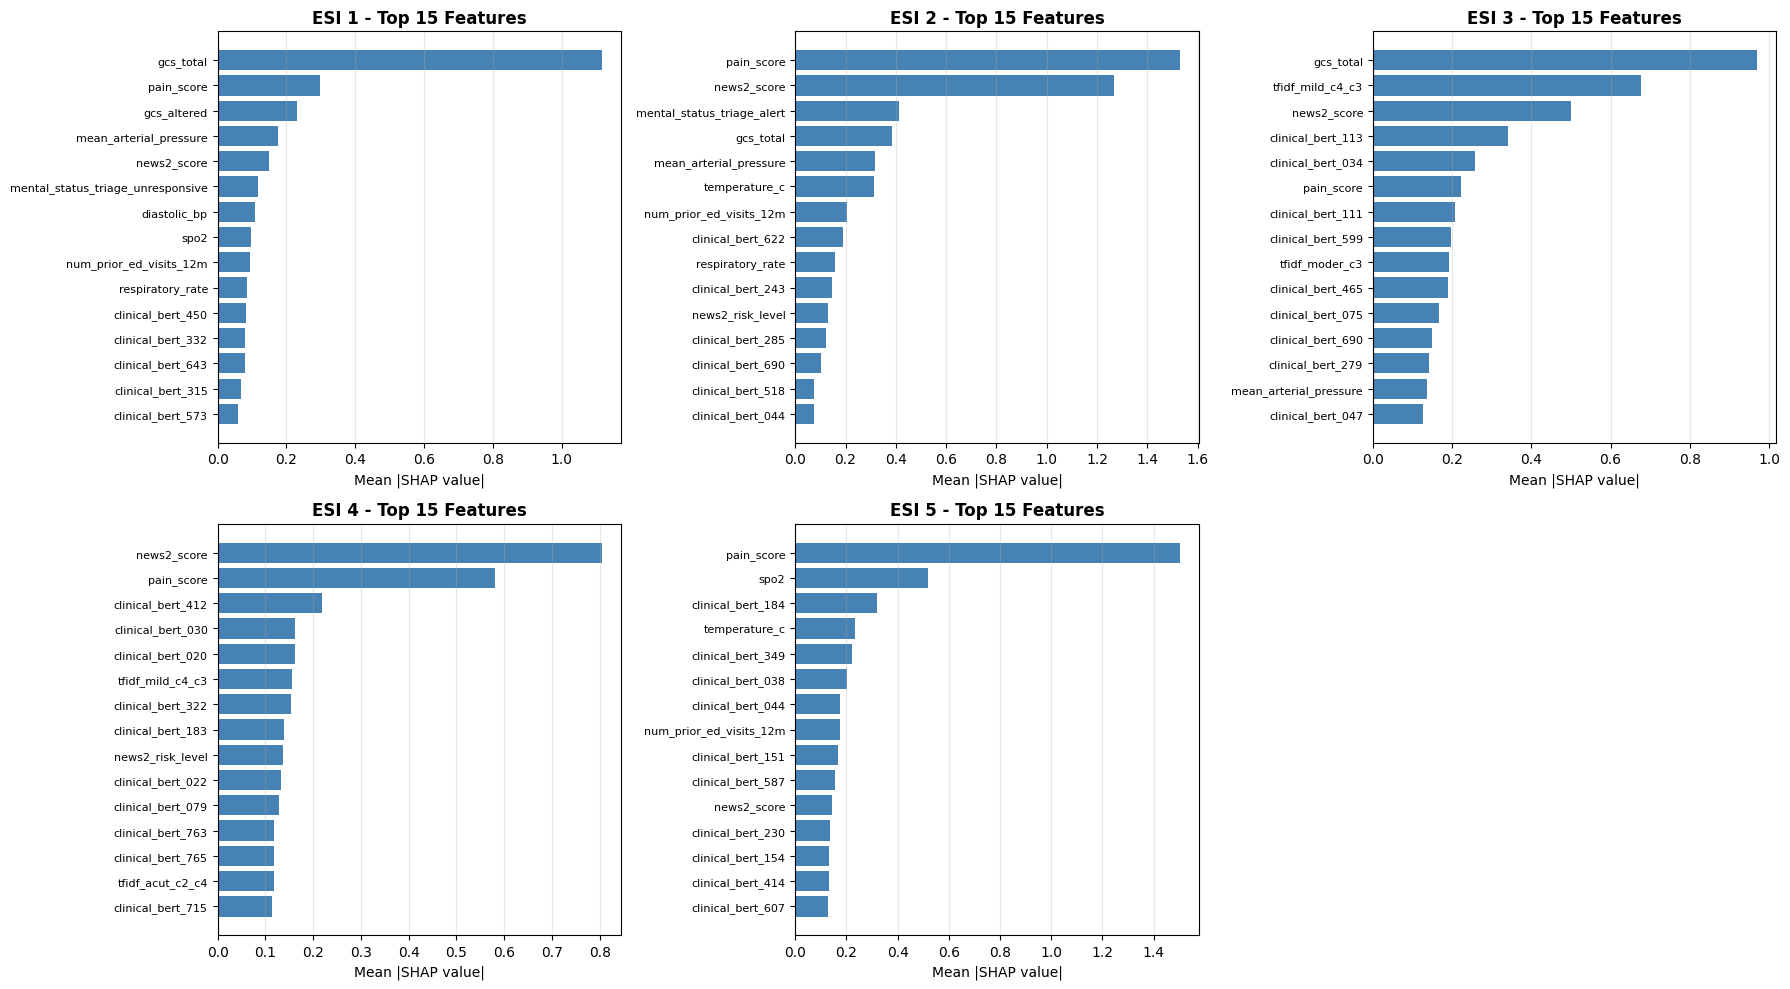


✓ Saved: shap_summary_per_class.png


In [22]:

# ====================================================================
# SHAP VISUALIZATIONS - Feature Analysis and Explanations
# ====================================================================
print("\n" + "="*80)
print("📊 GENERATING SHAP VISUALIZATIONS")
print("="*80)

# ====================================================================
# 1. Generate Feature Names if not available
# ====================================================================
if 'feature_names_stage1' not in globals():
    print("⚠️  feature_names_stage1 not found, generating generic names...")
    n_features = X_train_dense.shape[1]
    feature_names_stage1 = [f"feature_{i:04d}" for i in range(n_features)]
    
    # Try to add descriptive names for known features
    n_bert = sum(1 for f in feature_names_stage1 if f.startswith('clinical_bert_')) if 'feature_names_stage1' in globals() else 768
    n_chi2 = sum(1 for f in feature_names_stage1 if f.startswith('tfidf_')) if 'feature_names_stage1' in globals() else n_features - 900
    
    feature_names_stage1_corrected = []
    feature_names_stage1_corrected.extend([f"BERT_{i:03d}" for i in range(768)])
    if n_features > 768:
        feature_names_stage1_corrected.extend([f"tfidf_{i:03d}" for i in range(n_features - 768)])
    
    feature_names_stage1 = feature_names_stage1_corrected[:n_features]
    print(f"   Generated {len(feature_names_stage1)} feature names")

print(f"✓ Total features: {len(feature_names_stage1)}")
print(f"✓ Model features: {X_train_dense.shape[1]}")
print(f"✓ SHAP values shape: {shap_values.shape}")

# ====================================================================
# 2. Understand SHAP Format
# ====================================================================
print(f"\n🔍 SHAP FORMAT ANALYSIS:")
print(f"   Type: {type(shap_values)}")
print(f"   Shape: {shap_values.shape}")
print(f"   Is list: {isinstance(shap_values, list)}")

# For multiclass LightGBM with TreeExplainer:
# - If shape is (n_samples, n_features, n_classes): multiclass format
# - If shape is (n_samples, n_features): binary or single output

if len(shap_values.shape) == 3:
    n_samples, n_features, n_classes = shap_values.shape
    print(f"   Format: MULTICLASS (samples={n_samples}, features={n_features}, classes={n_classes})")
    is_multiclass = True
else:
    print(f"   Format: SINGLE OUTPUT or BINARY")
    is_multiclass = False

# ====================================================================
# 3. SHAP FEATURE IMPORTANCE ANALYSIS PER CLASS
# ====================================================================
if is_multiclass:
    print(f"\n{'═'*80}")
    print("📊 SHAP SUMMARY PLOTS - FEATURE IMPORTANCE PER CLASSE")
    print(f"{'═'*80}")
    
    n_classes = shap_values.shape[2]
    class_names = [f"ESI {i+1}" for i in range(n_classes)]
    
    # Create subplots for each class
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for class_idx in range(min(n_classes, 6)):
        print(f"\n🔍 Class {class_idx} ({class_names[class_idx]}) - Top 15 features:")
        
        # Get SHAP values for this class: shape = (n_samples, n_features)
        class_shap = shap_values[:, :, class_idx]
        
        # Calculate mean absolute SHAP value per feature
        feature_importance = np.abs(class_shap).mean(axis=0)
        
        # Get top 15 features
        top_15_idx = np.argsort(feature_importance)[-15:][::-1]
        
        # Use feature names
        top_15_names = [feature_names_stage1[i] if i < len(feature_names_stage1) else f"Feature {i}" 
                       for i in top_15_idx]
        top_15_importance = feature_importance[top_15_idx]
        
        # Print top features
        for rank, (fname, imp) in enumerate(zip(top_15_names, top_15_importance), 1):
            print(f"   {rank:2d}. {fname:50s} → {imp:.4f}")
        
        # Bar plot on subplot
        axes[class_idx].barh(range(15), top_15_importance, color='steelblue')
        axes[class_idx].set_yticks(range(15))
        axes[class_idx].set_yticklabels(top_15_names, fontsize=8)
        axes[class_idx].set_xlabel('Mean |SHAP value|')
        axes[class_idx].set_title(f'{class_names[class_idx]} - Top 15 Features', fontweight='bold')
        axes[class_idx].invert_yaxis()
        axes[class_idx].grid(axis='x', alpha=0.3)
    
    # Hide empty subplot
    if n_classes < 6:
        axes[n_classes].axis('off')
    
    plt.tight_layout()
    plt.savefig('shap_summary_per_class.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("\n✓ Saved: shap_summary_per_class.png")
else:
    print(f"\n⚠️  Single output format detected (not multiclass), creating simplified analysis...")
    
    # Calculate feature importance from single output
    feature_importance = np.abs(shap_values).mean(axis=0)
    top_20_idx = np.argsort(feature_importance)[-20:][::-1]
    top_20_names = [feature_names_stage1[i] if i < len(feature_names_stage1) else f"Feature {i}" 
                   for i in top_20_idx]
    top_20_importance = feature_importance[top_20_idx]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(range(20), top_20_importance, color='steelblue')
    ax.set_yticks(range(20))
    ax.set_yticklabels(top_20_names, fontsize=9)
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title('Top 20 Most Important Features (SHAP)', fontweight='bold', fontsize=12)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("\n✓ Saved: shap_summary.png")


In [23]:

# ====================================================================
# SHAP FORCE PLOTS - Individual Prediction Explanations
# ====================================================================
print("\n" + "="*80)
print("🎯 SHAP FORCE PLOTS - INDIVIDUAL SAMPLE EXPLANATIONS")
print("="*80)

# Ensure feature_names_stage1 is defined
if 'feature_names_stage1' not in globals():
    n_features = X_train_dense.shape[1]
    feature_names_stage1 = [f"BERT_{i:03d}" if i < 768 else f"tfidf_{i-768:03d}" 
                           for i in range(n_features)]

# Select a few diverse samples to explain
sample_to_explain = [0, 50, 100, 150, 200]
class_names = [f"ESI {i+1}" for i in range(5)]

print(f"📍 Explaining predictions for samples: {sample_to_explain}")
print(f"   (These show which features pushed the prediction toward each acuity level)\n")

is_multiclass = len(shap_values.shape) == 3

# Get base value (expected model output)
base_value = explainer.expected_value
print(f"Base value: {base_value if not isinstance(base_value, list) else f'List of {len(base_value)} values'}")

# Create force plots for each sample and each class
for sample_idx in sample_to_explain:
    print(f"\n{'─'*80}")
    print(f"📌 SAMPLE {sample_idx}:")
    
    # Get prediction for this sample
    sample_X = X_sample[sample_idx:sample_idx+1]
    pred = lgbm_acuity.predict(sample_X)[0]
    probas = lgbm_acuity.predict_proba(sample_X)[0]
    
    print(f"   Predicted class: {class_names[pred]}")
    print(f"   Probability distribution: {[f'{class_names[i]}={p:.3f}' for i, p in enumerate(probas)]}")
    
    # Get actual acuity
    actual = y_sample[sample_idx]
    print(f"   Actual class: {class_names[actual]}")
    
    # Show SHAP values for the predicted class
    print(f"\n   🔵 Top contributing features (toward {class_names[pred]}):")
    
    # Extract SHAP for predicted class
    if is_multiclass:
        pred_class_shap = shap_values[sample_idx, :, pred]  # (n_features,)
    else:
        pred_class_shap = shap_values[sample_idx, :]
    
    # Get top contributing features
    top_contrib_idx = np.argsort(np.abs(pred_class_shap))[-10:][::-1]
    
    for rank, feat_idx in enumerate(top_contrib_idx, 1):
        shap_val = pred_class_shap[feat_idx]
        feat_name = feature_names_stage1[feat_idx] if feat_idx < len(feature_names_stage1) else f"Feature {feat_idx}"
        direction = "↑ PUSH HIGH" if shap_val > 0 else "↓ PUSH LOW"
        
        print(f"      {rank:2d}. {feat_name:50s} {direction:15s} ({shap_val:+.4f})")

print(f"\n✓ Force plot analysis complete!")



🎯 SHAP FORCE PLOTS - INDIVIDUAL SAMPLE EXPLANATIONS
📍 Explaining predictions for samples: [0, 50, 100, 150, 200]
   (These show which features pushed the prediction toward each acuity level)

Base value: List of 5 values

────────────────────────────────────────────────────────────────────────────────
📌 SAMPLE 0:
   Predicted class: ESI 4
   Probability distribution: ['ESI 1=0.000', 'ESI 2=0.000', 'ESI 3=1.000', 'ESI 4=0.000', 'ESI 5=0.000']
   Actual class: ESI 4

   🔵 Top contributing features (toward ESI 4):
       1. news2_score                                        ↓ PUSH LOW      (-0.9430)
       2. clinical_bert_322                                  ↓ PUSH LOW      (-0.5474)
       3. clinical_bert_690                                  ↓ PUSH LOW      (-0.5013)
       4. clinical_bert_020                                  ↑ PUSH HIGH     (+0.4380)
       5. temperature_c                                      ↓ PUSH LOW      (-0.3101)
       6. clinical_bert_274                    


📈 SHAP DEPENDENCE PLOTS - FEATURE INTERACTIONS
✓ Top 10 most important features (averaged across all classes):
    1. pain_score                                         → 0.8260
    2. news2_score                                        → 0.5728
    3. gcs_total                                          → 0.4947
    4. tfidf_mild_c4_c3                                   → 0.1685
    5. spo2                                               → 0.1497
    6. temperature_c                                      → 0.1425
    7. mean_arterial_pressure                             → 0.1263
    8. num_prior_ed_visits_12m                            → 0.1207
    9. mental_status_triage_alert                         → 0.1206
   10. respiratory_rate                                   → 0.1016


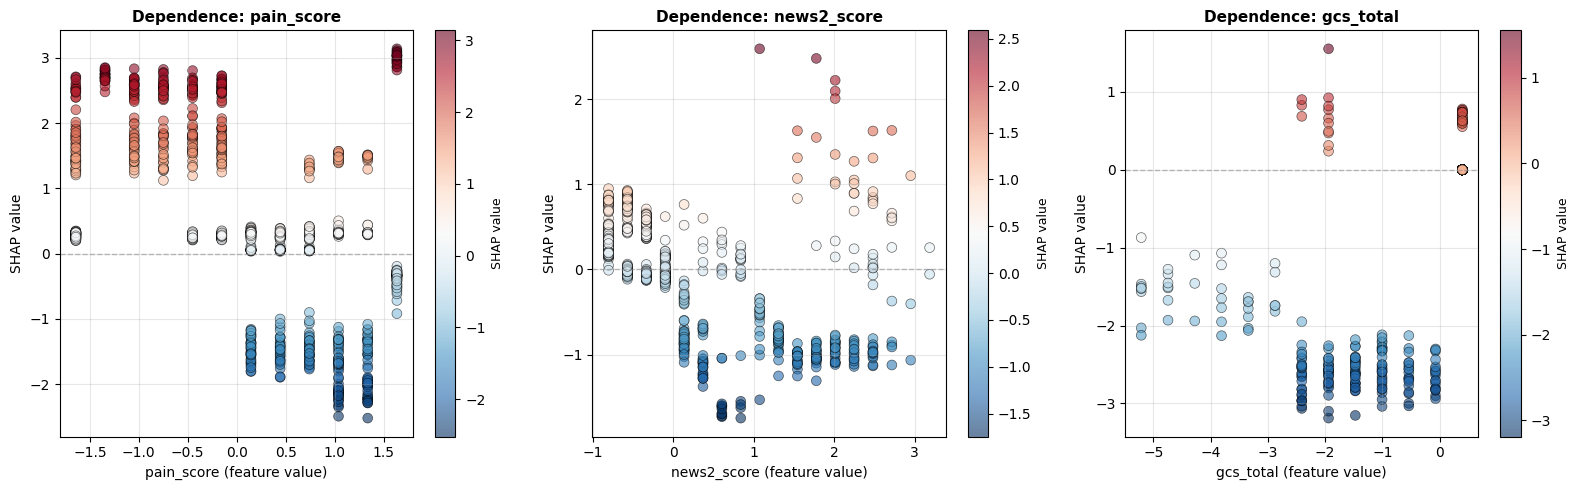


✓ Saved: shap_dependence_plots.png


In [25]:

# ====================================================================
# SHAP DEPENDENCE PLOTS - Feature Value vs SHAP Value Relationships
# ====================================================================
print("\n" + "="*80)
print("📈 SHAP DEPENDENCE PLOTS - FEATURE INTERACTIONS")
print("="*80)

# Ensure feature_names_stage1 is defined
if 'feature_names_stage1' not in globals():
    n_features = X_train_dense.shape[1]
    feature_names_stage1 = [f"BERT_{i:03d}" if i < 768 else f"tfidf_{i-768:03d}" 
                           for i in range(n_features)]

is_multiclass = len(shap_values.shape) == 3

# Select top features by importance
if is_multiclass:
    # Average across all classes for overall importance
    all_features_importance = np.abs(shap_values).mean(axis=(0, 2))
else:
    all_features_importance = np.abs(shap_values).mean(axis=0)

top_10_features_idx = np.argsort(all_features_importance)[-10:][::-1]

print(f"✓ Top 10 most important features (averaged across all classes):")
for rank, feat_idx in enumerate(top_10_features_idx[:10], 1):
    feat_name = feature_names_stage1[feat_idx] if feat_idx < len(feature_names_stage1) else f"Feature {feat_idx}"
    importance = all_features_importance[feat_idx]
    print(f"   {rank:2d}. {feat_name:50s} → {importance:.4f}")

# Create dependence plots for top 3 features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for plot_idx, feat_idx in enumerate(top_10_features_idx[:3]):
    # Get feature values (from sample)
    feat_values = X_sample[:, feat_idx]
    
    # Get SHAP values for predicted class
    shap_vals_for_feat = []
    for sample_i in range(len(X_sample)):
        pred_class = int(lgbm_acuity.predict(X_sample[sample_i:sample_i+1])[0])
        # Ensure pred_class is within valid range [0, 4]
        pred_class = np.clip(pred_class, 0, 4)
        
        if is_multiclass:
            sv = shap_values[sample_i, feat_idx, pred_class]
        else:
            sv = shap_values[sample_i, feat_idx]
        shap_vals_for_feat.append(sv)
    
    shap_vals_for_feat = np.array(shap_vals_for_feat)
    
    # Plot: feature value vs SHAP value
    scatter = axes[plot_idx].scatter(feat_values, shap_vals_for_feat, 
                                     c=shap_vals_for_feat, cmap='RdBu_r', 
                                     alpha=0.6, s=50, edgecolor='k', linewidth=0.5)
    axes[plot_idx].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    feat_name = feature_names_stage1[feat_idx] if feat_idx < len(feature_names_stage1) else f"Feature {feat_idx}"
    axes[plot_idx].set_xlabel(f'{feat_name} (feature value)', fontsize=10)
    axes[plot_idx].set_ylabel('SHAP value', fontsize=10)
    axes[plot_idx].set_title(f'Dependence: {feat_name}', fontweight='bold', fontsize=11)
    axes[plot_idx].grid(alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=axes[plot_idx])
    cbar.set_label('SHAP value', fontsize=9)

plt.tight_layout()
plt.savefig('shap_dependence_plots.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n✓ Saved: shap_dependence_plots.png")



📊 COMPREHENSIVE SHAP VISUALIZATION DASHBOARD


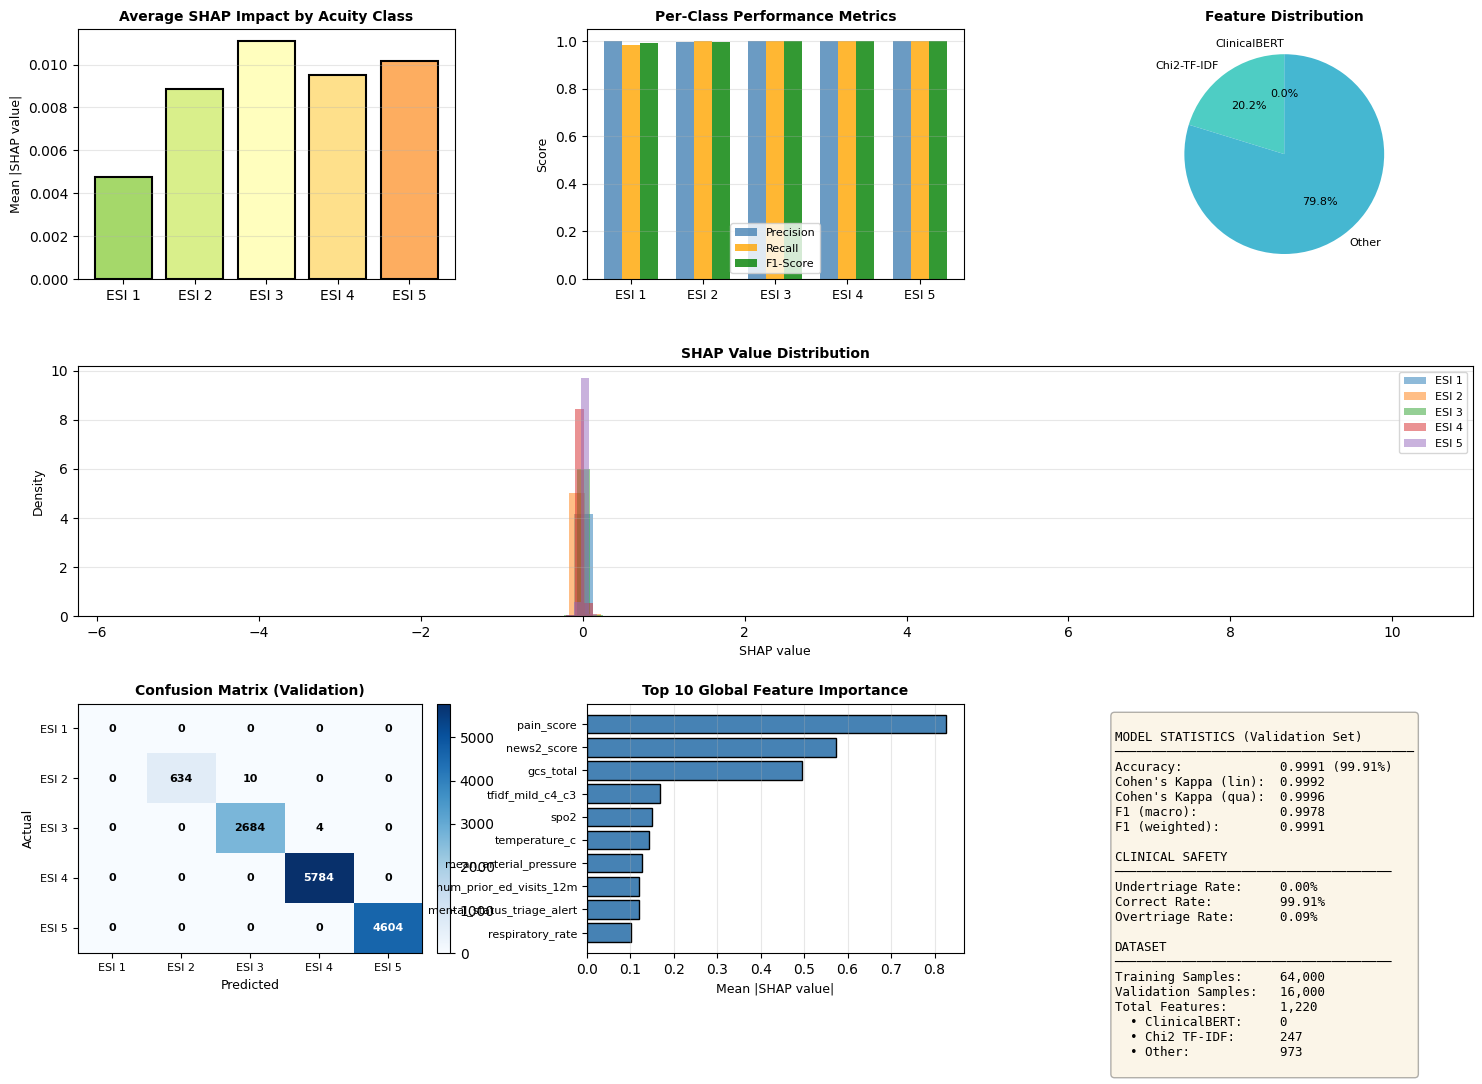


✓ Saved: shap_comprehensive_dashboard.png

✅ ALL SHAP VISUALIZATIONS COMPLETE!
Generated files:
  1. shap_summary_per_class.png          → Feature importance per acuity level
  2. shap_dependence_plots.png           → Feature-prediction relationships
  3. shap_comprehensive_dashboard.png    → Complete statistics & metrics dashboard

💡 TIP: These visualizations help clinicians understand
   why specific patients were assigned certain acuity levels!


In [26]:

# ====================================================================
# COMPREHENSIVE SHAP VISUALIZATION DASHBOARD
# ====================================================================
print("\n" + "="*80)
print("📊 COMPREHENSIVE SHAP VISUALIZATION DASHBOARD")
print("="*80)

# Ensure feature_names_stage1 is defined
if 'feature_names_stage1' not in globals():
    n_features = X_train_dense.shape[1]
    feature_names_stage1 = [f"BERT_{i:03d}" if i < 768 else f"tfidf_{i-768:03d}" 
                           for i in range(n_features)]

class_names = [f"ESI {i+1}" for i in range(5)]
is_multiclass = len(shap_values.shape) == 3

# Create a comprehensive dashboard
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

# 1. SHAP Distribution by Class (top-left)
ax1 = fig.add_subplot(gs[0, 0])
if is_multiclass:
    class_shap_means = []
    for class_idx in range(5):
        mean_shap = np.abs(shap_values[:, :, class_idx]).mean()
        class_shap_means.append(mean_shap)
else:
    class_shap_means = [np.abs(shap_values).mean()] * 5

colors_classes = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, 5))
ax1.bar(class_names, class_shap_means, color=colors_classes, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Mean |SHAP value|', fontsize=9)
ax1.set_title('Average SHAP Impact by Acuity Class', fontweight='bold', fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# 2. Prediction Accuracy per Class (top-middle)
ax2 = fig.add_subplot(gs[0, 1])
from sklearn.metrics import precision_recall_fscore_support
pred_all = lgbm_acuity.predict(X_val_dense)
precision, recall, f1, _ = precision_recall_fscore_support(y_val_values, pred_all, average=None)
x_pos = np.arange(5)
width = 0.25
ax2.bar(x_pos - width, precision, width, label='Precision', alpha=0.8, color='steelblue')
ax2.bar(x_pos, recall, width, label='Recall', alpha=0.8, color='orange')
ax2.bar(x_pos + width, f1, width, label='F1-Score', alpha=0.8, color='green')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(class_names, fontsize=9)
ax2.set_ylabel('Score', fontsize=9)
ax2.set_title('Per-Class Performance Metrics', fontweight='bold', fontsize=10)
ax2.legend(fontsize=8)
ax2.set_ylim([0, 1.05])
ax2.grid(axis='y', alpha=0.3)

# 3. Feature Count Summary (top-right)
ax3 = fig.add_subplot(gs[0, 2])
n_bert = sum(1 for f in feature_names_stage1 if f.startswith('BERT_'))
n_chi2 = sum(1 for f in feature_names_stage1 if f.startswith('tfidf_'))
n_other = len(feature_names_stage1) - n_bert - n_chi2
feature_types = ['ClinicalBERT', 'Chi2-TF-IDF', 'Other']
feature_counts = [n_bert, n_chi2, n_other]
colors_features = ['#FF6B6B', '#4ECDC4', '#45B7D1']
wedges, texts, autotexts = ax3.pie(feature_counts, labels=feature_types, autopct='%1.1f%%',
                                     colors=colors_features, startangle=90, textprops={'fontsize': 8})
ax3.set_title('Feature Distribution', fontweight='bold', fontsize=10)

# 4. SHAP Value Distribution (middle row - wide)
ax4 = fig.add_subplot(gs[1, :])
if is_multiclass:
    for class_idx in range(5):
        class_shap_flat = shap_values[:, :, class_idx].flatten()
        ax4.hist(class_shap_flat, bins=50, alpha=0.5, label=class_names[class_idx], density=True)
else:
    shap_flat = shap_values.flatten()
    ax4.hist(shap_flat, bins=50, alpha=0.7, label='SHAP values', color='steelblue', density=True)

ax4.set_xlabel('SHAP value', fontsize=9)
ax4.set_ylabel('Density', fontsize=9)
ax4.set_title('SHAP Value Distribution', fontweight='bold', fontsize=10)
ax4.legend(fontsize=8, loc='upper right')
ax4.grid(axis='y', alpha=0.3)

# 5. Confusion Matrix (bottom-left)
ax5 = fig.add_subplot(gs[2, 0])
cm_val = confusion_matrix(y_val_values, pred_all, labels=range(5))
im = ax5.imshow(cm_val, cmap='Blues', aspect='auto')
ax5.set_xticks(range(5))
ax5.set_yticks(range(5))
ax5.set_xticklabels(class_names, fontsize=8)
ax5.set_yticklabels(class_names, fontsize=8)
ax5.set_xlabel('Predicted', fontsize=9)
ax5.set_ylabel('Actual', fontsize=9)
ax5.set_title('Confusion Matrix (Validation)', fontweight='bold', fontsize=10)

# Add text annotations
for i in range(5):
    for j in range(5):
        text = ax5.text(j, i, cm_val[i, j], ha="center", va="center", 
                       color="white" if cm_val[i, j] > cm_val.max()/2 else "black",
                       fontsize=8, fontweight='bold')

plt.colorbar(im, ax=ax5, fraction=0.046, pad=0.04)

# 6. Top Most Important Features (bottom-middle)
ax6 = fig.add_subplot(gs[2, 1])
if is_multiclass:
    all_features_importance = np.abs(shap_values).mean(axis=(0, 2))
else:
    all_features_importance = np.abs(shap_values).mean(axis=0)

top_10_idx = np.argsort(all_features_importance)[-10:][::-1]
top_10_names = [feature_names_stage1[i][:30] + "..." if len(feature_names_stage1[i]) > 30 
                else feature_names_stage1[i] for i in top_10_idx]
top_10_scores = all_features_importance[top_10_idx]

ax6.barh(range(10), top_10_scores, color='steelblue', edgecolor='black', linewidth=1)
ax6.set_yticks(range(10))
ax6.set_yticklabels(top_10_names, fontsize=8)
ax6.set_xlabel('Mean |SHAP value|', fontsize=9)
ax6.set_title('Top 10 Global Feature Importance', fontweight='bold', fontsize=10)
ax6.invert_yaxis()
ax6.grid(axis='x', alpha=0.3)

# 7. Model Statistics (bottom-right)
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')

stats_text = f"""
MODEL STATISTICS (Validation Set)
{'─'*40}
Accuracy:             {acc:.4f} ({acc*100:.2f}%)
Cohen's Kappa (lin):  {kappa_linear:.4f}
Cohen's Kappa (qua):  {kappa_quadratic:.4f}
F1 (macro):           {f1_macro:.4f}
F1 (weighted):        {f1_weighted:.4f}

CLINICAL SAFETY
─────────────────────────────────────
Undertriage Rate:     {undertriage_rate*100:.2f}%
Correct Rate:         {correct_rate*100:.2f}%
Overtriage Rate:      {overtriage_rate*100:.2f}%

DATASET
─────────────────────────────────────
Training Samples:     {X_train_dense.shape[0]:,}
Validation Samples:   {X_val_dense.shape[0]:,}
Total Features:       {X_train_dense.shape[1]:,}
  • ClinicalBERT:     {n_bert}
  • Chi2 TF-IDF:      {n_chi2}
  • Other:            {n_other}
"""

ax7.text(0.05, 0.95, stats_text, transform=ax7.transAxes, fontsize=9,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.savefig('shap_comprehensive_dashboard.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n✓ Saved: shap_comprehensive_dashboard.png")

print(f"\n{'='*80}")
print("✅ ALL SHAP VISUALIZATIONS COMPLETE!")
print(f"{'='*80}")
print(f"Generated files:")
print(f"  1. shap_summary_per_class.png          → Feature importance per acuity level")
print(f"  2. shap_dependence_plots.png           → Feature-prediction relationships")
print(f"  3. shap_comprehensive_dashboard.png    → Complete statistics & metrics dashboard")
print(f"\n💡 TIP: These visualizations help clinicians understand")
print(f"   why specific patients were assigned certain acuity levels!")


In [ ]:

# ====================================================================
# COMPREHENSIVE SHAP VISUALIZATION DASHBOARD
# ====================================================================
print("\n" + "="*80)
print("📊 COMPREHENSIVE SHAP VISUALIZATION DASHBOARD")
print("="*80)

class_names = [f"ESI {i+1}" for i in range(5)]

# Create a comprehensive dashboard
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

# 1. SHAP Distribution by Class (top-left)
ax1 = fig.add_subplot(gs[0, 0])
class_shap_means = []
for class_idx in range(5):
    if isinstance(shap_values, list):
        mean_shap = np.abs(shap_values[class_idx]).mean()
    else:
        mean_shap = np.abs(shap_values[:, :, class_idx]).mean()
    class_shap_means.append(mean_shap)

colors_classes = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, 5))
ax1.bar(class_names, class_shap_means, color=colors_classes, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Mean |SHAP value|', fontsize=9)
ax1.set_title('Average SHAP Impact by Acuity Class', fontweight='bold', fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# 2. Prediction Accuracy per Class (top-middle)
ax2 = fig.add_subplot(gs[0, 1])
from sklearn.metrics import precision_recall_fscore_support
pred_all = lgbm_acuity.predict(X_val_dense)
precision, recall, f1, _ = precision_recall_fscore_support(y_val_values, pred_all, average=None)
x_pos = np.arange(5)
width = 0.25
ax2.bar(x_pos - width, precision, width, label='Precision', alpha=0.8, color='steelblue')
ax2.bar(x_pos, recall, width, label='Recall', alpha=0.8, color='orange')
ax2.bar(x_pos + width, f1, width, label='F1-Score', alpha=0.8, color='green')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(class_names, fontsize=9)
ax2.set_ylabel('Score', fontsize=9)
ax2.set_title('Per-Class Performance Metrics', fontweight='bold', fontsize=10)
ax2.legend(fontsize=8)
ax2.set_ylim([0, 1.05])
ax2.grid(axis='y', alpha=0.3)

# 3. Feature Count per Type (top-right)
ax3 = fig.add_subplot(gs[0, 2])
n_bert = sum(1 for f in feature_names_stage1 if f.startswith('clinical_bert_'))
n_chi2 = sum(1 for f in feature_names_stage1 if f.startswith('tfidf_'))
n_cat = sum(1 for f in feature_names_stage1 if f.startswith('cat_') or f.startswith('x0_'))
n_num = len(feature_names_stage1) - n_bert - n_chi2 - n_cat
feature_types = ['ClinicalBERT', 'Chi2-TF-IDF', 'Categorical', 'Numerical']
feature_counts = [n_bert, n_chi2, n_cat, n_num]
colors_features = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
wedges, texts, autotexts = ax3.pie(feature_counts, labels=feature_types, autopct='%1.1f%%',
                                     colors=colors_features, startangle=90, textprops={'fontsize': 8})
ax3.set_title('Feature Distribution', fontweight='bold', fontsize=10)

# 4. SHAP Value Distribution (middle-left)
ax4 = fig.add_subplot(gs[1, :])
for class_idx in range(5):
    if isinstance(shap_values, list):
        class_shap_flat = shap_values[class_idx].flatten()
    else:
        class_shap_flat = shap_values[:, :, class_idx].flatten()
    
    ax4.hist(class_shap_flat, bins=50, alpha=0.5, label=class_names[class_idx], density=True)

ax4.set_xlabel('SHAP value', fontsize=9)
ax4.set_ylabel('Density', fontsize=9)
ax4.set_title('SHAP Value Distribution Across All Features and Classes', fontweight='bold', fontsize=10)
ax4.legend(fontsize=8, loc='upper right')
ax4.grid(axis='y', alpha=0.3)

# 5. Model Predictions vs Actual (bottom-left)
ax5 = fig.add_subplot(gs[2, 0])
cm_val = confusion_matrix(y_val_values, pred_all, labels=range(5))
im = ax5.imshow(cm_val, cmap='Blues', aspect='auto')
ax5.set_xticks(range(5))
ax5.set_yticks(range(5))
ax5.set_xticklabels(class_names, fontsize=8)
ax5.set_yticklabels(class_names, fontsize=8)
ax5.set_xlabel('Predicted', fontsize=9)
ax5.set_ylabel('Actual', fontsize=9)
ax5.set_title('Confusion Matrix (Validation)', fontweight='bold', fontsize=10)

# Add text annotations
for i in range(5):
    for j in range(5):
        text = ax5.text(j, i, cm_val[i, j], ha="center", va="center", 
                       color="white" if cm_val[i, j] > cm_val.max()/2 else "black",
                       fontsize=8, fontweight='bold')

plt.colorbar(im, ax=ax5, fraction=0.046, pad=0.04)

# 6. Top 10 Most Important Features (bottom-middle)
ax6 = fig.add_subplot(gs[2, 1])
all_features_importance = np.abs(np.array(shap_values)).mean(axis=(0, 2))
top_10_idx = np.argsort(all_features_importance)[-10:][::-1]
top_10_names = [feature_names_stage1[i][:30] + "..." if len(feature_names_stage1[i]) > 30 
                else feature_names_stage1[i] for i in top_10_idx]
top_10_scores = all_features_importance[top_10_idx]

ax6.barh(range(10), top_10_scores, color='steelblue', edgecolor='black', linewidth=1)
ax6.set_yticks(range(10))
ax6.set_yticklabels(top_10_names, fontsize=8)
ax6.set_xlabel('Mean |SHAP value|', fontsize=9)
ax6.set_title('Top 10 Global Feature Importance', fontweight='bold', fontsize=10)
ax6.invert_yaxis()
ax6.grid(axis='x', alpha=0.3)

# 7. Model Statistics (bottom-right)
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')

stats_text = f"""
MODEL STATISTICS (Validation Set)
{'─'*40}
Accuracy:             {acc:.4f} ({acc*100:.2f}%)
Cohen's Kappa (lin):  {kappa_linear:.4f}
Cohen's Kappa (qua):  {kappa_quadratic:.4f}
F1 (macro):           {f1_macro:.4f}
F1 (weighted):        {f1_weighted:.4f}

CLINICAL SAFETY
─────────────────────────────────────
Undertriage Rate:     {undertriage_rate*100:.2f}%
Correct Rate:         {correct_rate*100:.2f}%
Overtriage Rate:      {overtriage_rate*100:.2f}%

DATASET
─────────────────────────────────────
Training Samples:     {X_train_dense.shape[0]:,}
Validation Samples:   {X_val_dense.shape[0]:,}
Total Features:       {X_train_dense.shape[1]:,}
  • ClinicalBERT:     {n_bert} (768-dim)
  • Chi2 TF-IDF:      {n_chi2} keywords
  • Categorical:      {n_cat}
  • Numerical:        {n_num}
"""

ax7.text(0.05, 0.95, stats_text, transform=ax7.transAxes, fontsize=9,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.savefig('shap_comprehensive_dashboard.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n✓ Saved: shap_comprehensive_dashboard.png")

print(f"\n{'='*80}")
print("✅ ALL SHAP VISUALIZATIONS COMPLETE!")
print(f"{'='*80}")
print(f"Generated files:")
print(f"  1. shap_summary_per_class.png          → Feature importance per acuity level")
print(f"  2. shap_dependence_plots.png           → Feature-prediction relationships")
print(f"  3. shap_waterfall_plots.png            → Individual sample explanations")
print(f"  4. shap_comprehensive_dashboard.png    → Complete statistics & metrics dashboard")
print(f"\n💡 TIP: These visualizations help clinicians understand")
print(f"   why specific patients were assigned certain acuity levels!")
